In [1]:
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
import jax
import jax.numpy as jnp
import inspeqtor.experimental as sq
import pathlib
# import psd_model as ml
import gen_data_v2 as ml
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots as scienceplots
import time

In [3]:
EXPERIMENT_ID = "0002-fixed"
data_path = pathlib.Path(f"./data/PSD/{EXPERIMENT_ID}")
# Ensure that path to dataset exists
assert data_path.exists()
# Read the noise setting first
config = sq.data.ExperimentConfiguration.from_file(data_path)

# Read the noise setting first
noise_config = config.additional_info
DETUNE = float(noise_config["DETUNE"])
NOISE_STR = float(noise_config["NOISE_STR"])
TROTTERIZATION = bool(noise_config["TROTTERIZATION"])
TROTTER_STEPS = int(noise_config["TROTTER_STEPS"])

print(noise_config)

# # Setup model path
model_path = pathlib.Path(f"model/PSD/{EXPERIMENT_ID}/SGM")
model_path.mkdir(parents=True, exist_ok=True)

{'NOISE_STR': 0.01, 'TROTTERIZATION': True, 'TROTTER_STEPS': 8192, 'DETUNE': 0.001}


In [4]:
loaded_data = sq.predefined.load_data_from_path(
    data_path,
    hamiltonian_spec=sq.predefined.HamiltonianSpec(
        method=sq.predefined.WhiteboxStrategy.TROTTER
        if TROTTERIZATION
        else sq.predefined.WhiteboxStrategy.ODE,
        trotter_steps=TROTTER_STEPS,
    ),
)
data_model = ml.get_data_model(
    detune=DETUNE,
    noise_str=NOISE_STR,
    trotter_steps=TROTTER_STEPS,
)

key = jax.random.key(0)
key, random_split_key, train_key, prediction_key = jax.random.split(key, 4)
(
    train_control_parameters,
    train_unitaries,
    train_expectation_values,
    test_control_parameters,
    test_unitaries,
    test_expectation_values,
) = sq.utils.random_split(
    random_split_key,
    int(loaded_data.control_parameters.shape[0] * 0.1),  # Test size
    loaded_data.control_parameters,
    loaded_data.unitaries,
    loaded_data.expectation_values,
)

shots = loaded_data.experiment_data.experiment_config.shots

train_data = sq.optimize.DataBundled(
    control_params=ml.feature_map(train_control_parameters),
    unitaries=train_unitaries,
    observables=train_expectation_values,
)

test_data = sq.optimize.DataBundled(
    control_params=ml.feature_map(test_control_parameters),
    unitaries=test_unitaries,
    observables=test_expectation_values,
)

In [5]:
from tqdm.notebook import tqdm # Use tqdm.notebook for a nice bar in Jupyter

In [6]:
model = sq.models.linen.WoModel(
    hidden_sizes_1=[5],
    hidden_sizes_2=[5],
)

NUM_EPOCH = 1000
optimizer = sq.optimize.get_default_optimizer(8 * NUM_EPOCH)

key = jax.random.key(0)
key, init_key, loader_key, train_key = jax.random.split(key, 4)

BATCH_SIZE = test_data.control_params.shape[0]
# Initialize the model parameters

loss_fn = sq.models.linen.make_loss_fn(
    adapter_fn=sq.model.observable_to_expvals,
    model=model,
    loss_metric=sq.model.LossMetric.MSEE,
)

pbar = tqdm(total=NUM_EPOCH, desc="Training Progress")
# --- 2. Define the Callback Function to Update tqdm ---
def callback_fn(model_params, opt_state, history_entry: list[sq.optimize.HistoryEntryV3]):
    """
    This callback is called after each epoch. It updates the tqdm progress bar
    with the latest loss metrics.
    """
    # The history contains train, validation, and test entries in order
    train_entry = history_entry[-3]
    val_entry = history_entry[-2]
    test_entry = history_entry[-1]
    
    # Update the postfix of the bar to display the latest loss values
    pbar.set_postfix({
        "Train Loss": f"{train_entry.loss:.5f}",
        "Val Loss": f"{val_entry.loss:.5f}",
        "Test Loss": f"{test_entry.loss:.5f}",
    })
    
    # Increment the progress bar by 1 step (for one completed epoch)
    pbar.update(1)

start_time = time.time()
model_params, _, histories = sq.models.linen.train_model(
    train_key,
    train_data,
    test_data,
    test_data,
    model,
    optimizer,
    loss_fn,
    callbacks=[callback_fn],
    NUM_EPOCH=NUM_EPOCH,
)
stop_time = time.time()
print(stop_time - start_time)

Training Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

15.029889106750488


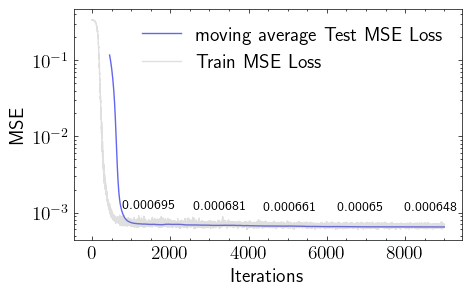

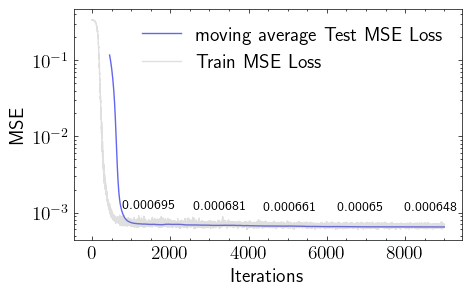

In [7]:
raw_data = sq.optimize.clean_history_entries(histories)
df = pd.DataFrame(raw_data)
df.to_csv(model_path / "training_loss.csv")

rescaled_train_losses = jnp.asarray(df[df["loop"] == "train"]["loss"].to_numpy())
rescaled_eval_losses = jnp.asarray(df[df["loop"] == "test"]["loss"].to_numpy())

iterations = jnp.arange(len(rescaled_train_losses))
with plt.style.context(["science"]):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax = sq.visualization.plot_loss_with_moving_average(
        df.query("loop == 'test'")["step"].to_numpy(),
        df.query("loop == 'test'")["loss"].to_numpy(),
        ax=ax,
        color="#6366f1",
        label="moving average Test MSE Loss",
        # annotate_at=[]
    )
    ax = sq.visualization.plot_loss_with_moving_average(
        df.query("loop == 'train'")["step"].to_numpy(),
        df.query("loop == 'train'")["loss"].to_numpy(),
        ax,
        window=1,
        annotate_at=[],
        color="gray",
        alpha=0.25,
        label="Train MSE Loss",
    )
    ax.set_yscale("log")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("MSE")
    ax.legend()
    sq.visualization.set_fontsize(ax, 14)

fig.savefig("fig_sgm_training_loss.pdf")

fig

In [8]:
model_state = sq.model.ModelData(
    config={
        "hidden_sizes_1": model.hidden_sizes_1,
        "hidden_sizes_2": model.hidden_sizes_1,
    },
    params=model_params,
)

model_state.to_file(model_path / "model.json")

In [9]:
model_state = sq.model.ModelData.from_file(model_path / "model.json")

In [10]:
predictive_fn = sq.models.linen.make_predictive_fn(
    sq.model.observable_to_expvals,
    sq.models.linen.WoModel(**model_state.config),
    model_state.params,
)

In [11]:
import typing

sx_agf_fn = sq.physics.direct_AGF_estimation_fn(sq.constant.SX)

maxiter = 1000
pbar = tqdm(total=maxiter, desc="Optimal Control Progress")


def callback_fn(step_idx, aux):
    # Update the postfix of the bar to display the latest loss values
    pbar.set_postfix({"AGF": aux["AGF"]})
    # Increment the progress bar by 1 step (for one completed epoch)
    pbar.update(1)


def loss_fn(params: jnp.ndarray) -> tuple[jnp.ndarray, typing.Any]:
    # Calculate the unitary using whitebox
    unitary = jax.jit(loaded_data.whitebox)(params)[-1]

    predicted_expvals = predictive_fn(ml.feature_map(params), unitary)

    agfs = sx_agf_fn(predicted_expvals)

    # Compute the cost.
    loss = (1 - agfs) ** 2
    return loss, {"AGF": agfs.mean(), "loss": loss}


init_params = loaded_data.control_sequence.sample_params(jax.random.key(0))
lower, upper = loaded_data.control_sequence.get_bounds()
_, l2a_fn = sq.control.get_param_array_converter(
    control_sequence=loaded_data.control_sequence
)

start_time = time.time()
res = sq.optimize.minimize(
    l2a_fn(init_params),
    jax.jit(loss_fn),
    sq.optimize.get_default_optimizer(maxiter),
    l2a_fn(lower),
    l2a_fn(upper),
    maxiter=maxiter,
    callbacks=[callback_fn],
)
stop_time = time.time()
print(stop_time - start_time, "second")

Optimal Control Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

98.00674200057983 second


In [12]:
print("The optimized control paramters: ", res[-1][-1]['params'].item())
print("With AGF of ",res[-1][-1]['AGF'].item())

The optimized control paramters:  1.3841126903078804
With AGF of  0.9996406546772627


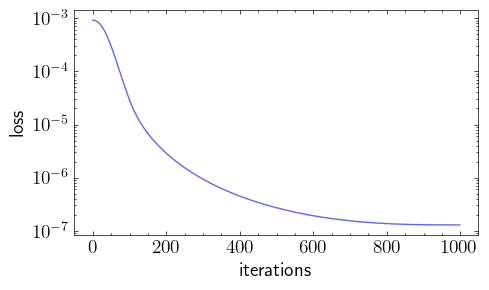

In [13]:
_, aux = res
control_loss = jnp.array([a["loss"] for a in aux])
with plt.style.context("science"):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(control_loss, color="#6366f1")
    ax.set_yscale("log")
    ax.set_ylabel("loss")
    ax.set_xlabel("iterations")
    sq.visualization.set_fontsize(ax, 14)

fig.tight_layout()
fig.savefig("fig_sgm_control_loss.pdf")
fig

In [14]:
import numpy as np

df = pd.DataFrame({"loss": np.array(control_loss)})
df.to_csv(model_path / "control_loss.csv")